# Model Evaluation

In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

root = Path.cwd().resolve()
for parent in [root] + list(root.parents):
    if (parent / "ml_engine").exists():
        sys.path.insert(0, str(parent))
        break
else:
    sys.path.insert(0, str(root))

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from ml_engine.evaluation import evaluate_model, plot_confusion_matrix, classification_report_summary, roc_curve_plot, precision_recall_curve_plot, threshold_analysis
from ml_engine.predict import load_models, predict_provider, predict_probability

sns.set_style("whitegrid")
sns.set_palette("Set2")

In [2]:
final_df = pd.read_csv('provider_master.csv')
from ml_engine.predict import load_models
models = load_models('../models/logistic_regression.pkl', '../models/random_forest.pkl', '../models/xgboost.pkl')

In [3]:
CORE_FEATURES = [
    "TotalClaims", "TotalReimbursed", "AvgReimbursed",
    "AvgClaimDuration", "AvgDaysInHospital",
    "UniquePatients", "UniqueAttendPhys",
    "SameAttendOperRate", "AvgChronicConds", "InpatientRatio",
]
X = final_df[CORE_FEATURES]
y = final_df['FraudLabel']

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = joblib.load('../models/scaler.pkl')
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=CORE_FEATURES, index=X_test.index)

              precision    recall  f1-score   support

   Not Fraud       0.99      0.90      0.94       981
       Fraud       0.46      0.88      0.61       101

    accuracy                           0.89      1082
   macro avg       0.73      0.89      0.77      1082
weighted avg       0.94      0.89      0.91      1082



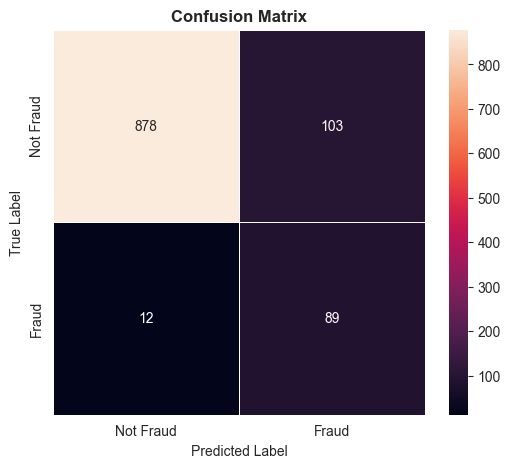

In [6]:
lr_model = models['lr']
results = evaluate_model(lr_model, X_test_scaled, y_test)
print(results['classification_report'])
plot_confusion_matrix(results['confusion_matrix'])

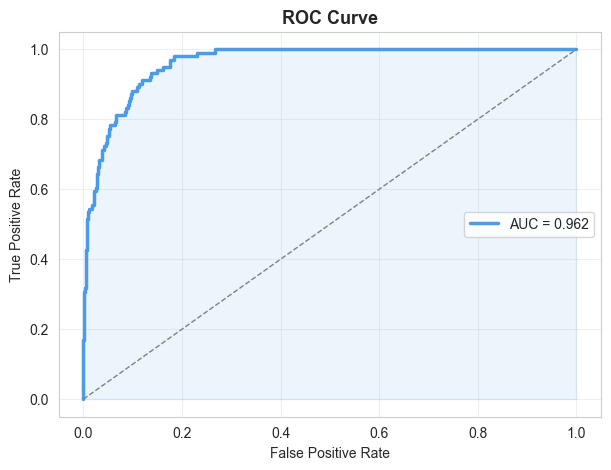

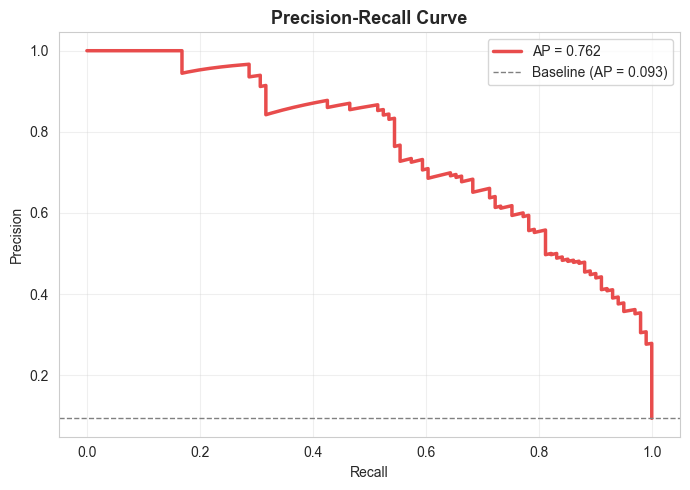

In [7]:
roc_curve_plot(y_test, results['y_proba'])
precision_recall_curve_plot(y_test, results['y_proba'])

In [8]:
thresholds_to_try = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
results_table = threshold_analysis(y_test, results['y_proba'], thresholds_to_try)
for row in results_table:
    print(row)

{'threshold': 0.2, 'precision': 0.2650918635170604, 'recall': 1.0, 'f1': 0.4190871369294606, 'caught_fraud': np.int64(101), 'total_fraud': np.int64(101)}
{'threshold': 0.3, 'precision': 0.35251798561151076, 'recall': 0.9702970297029703, 'f1': 0.5171503957783641, 'caught_fraud': np.int64(98), 'total_fraud': np.int64(101)}
{'threshold': 0.4, 'precision': 0.416289592760181, 'recall': 0.9108910891089109, 'f1': 0.5714285714285714, 'caught_fraud': np.int64(92), 'total_fraud': np.int64(101)}
{'threshold': 0.5, 'precision': 0.4635416666666667, 'recall': 0.8811881188118812, 'f1': 0.6075085324232082, 'caught_fraud': np.int64(89), 'total_fraud': np.int64(101)}
{'threshold': 0.6, 'precision': 0.5061728395061729, 'recall': 0.8118811881188119, 'f1': 0.623574144486692, 'caught_fraud': np.int64(82), 'total_fraud': np.int64(101)}
{'threshold': 0.7, 'precision': 0.5683453237410072, 'recall': 0.7821782178217822, 'f1': 0.6583333333333333, 'caught_fraud': np.int64(79), 'total_fraud': np.int64(101)}


In [9]:
# Final business summary
accuracy = results['accuracy']
precision = results['precision']
recall = results['recall']
f1 = results['f1']
auc_roc = results['roc_auc']
ap_score = results['avg_precision']
cm = results['confusion_matrix']
TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

print("FINAL PROJECT SUMMARY")
print(f"Accuracy  : {accuracy*100:.1f}%")
print(f"Precision : {precision*100:.1f}%")
print(f"Recall    : {recall*100:.1f}%")
print(f"F1-Score  : {f1*100:.1f}%")
print(f"AUC-ROC   : {auc_roc:.3f}")
print(f"PR-AUC    : {ap_score:.3f}")
print(f"TN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}")

FINAL PROJECT SUMMARY
Accuracy  : 89.4%
Precision : 46.4%
Recall    : 88.1%
F1-Score  : 60.8%
AUC-ROC   : 0.962
PR-AUC    : 0.762
TN: 878, FP: 103, FN: 12, TP: 89
